# (17) higher beta: (16, 24.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 64.0

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

poisson_vH16_t-16_z-[512]_cl-10,10_<grad|lin>
b200-ep300-lr(0.002)_beta(64:0.1)_temp(0.01:0.5)_gr(500)_(2025_02_21,10:10)

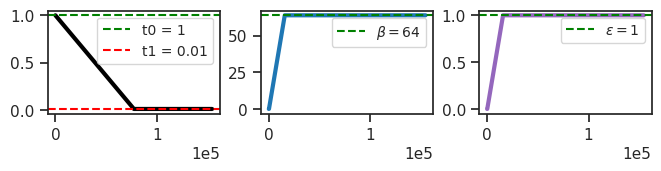

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
# tr.model.layer.update_n_exp(0.3)
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [7]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),)

In [ ]:
tr.train()

epoch # 292, avg loss: 314.937642:  97%|███▉| 292/300 [1:40:41<02:38, 19.77s/it]

In [9]:
print(tr.model.layer.n_exp)

tensor([ 5,  5,  7,  9, 13, 17, 21, 25, 28, 31, 32, 33, 34, 34, 34, 35],
       device='cuda:0', dtype=torch.int32)

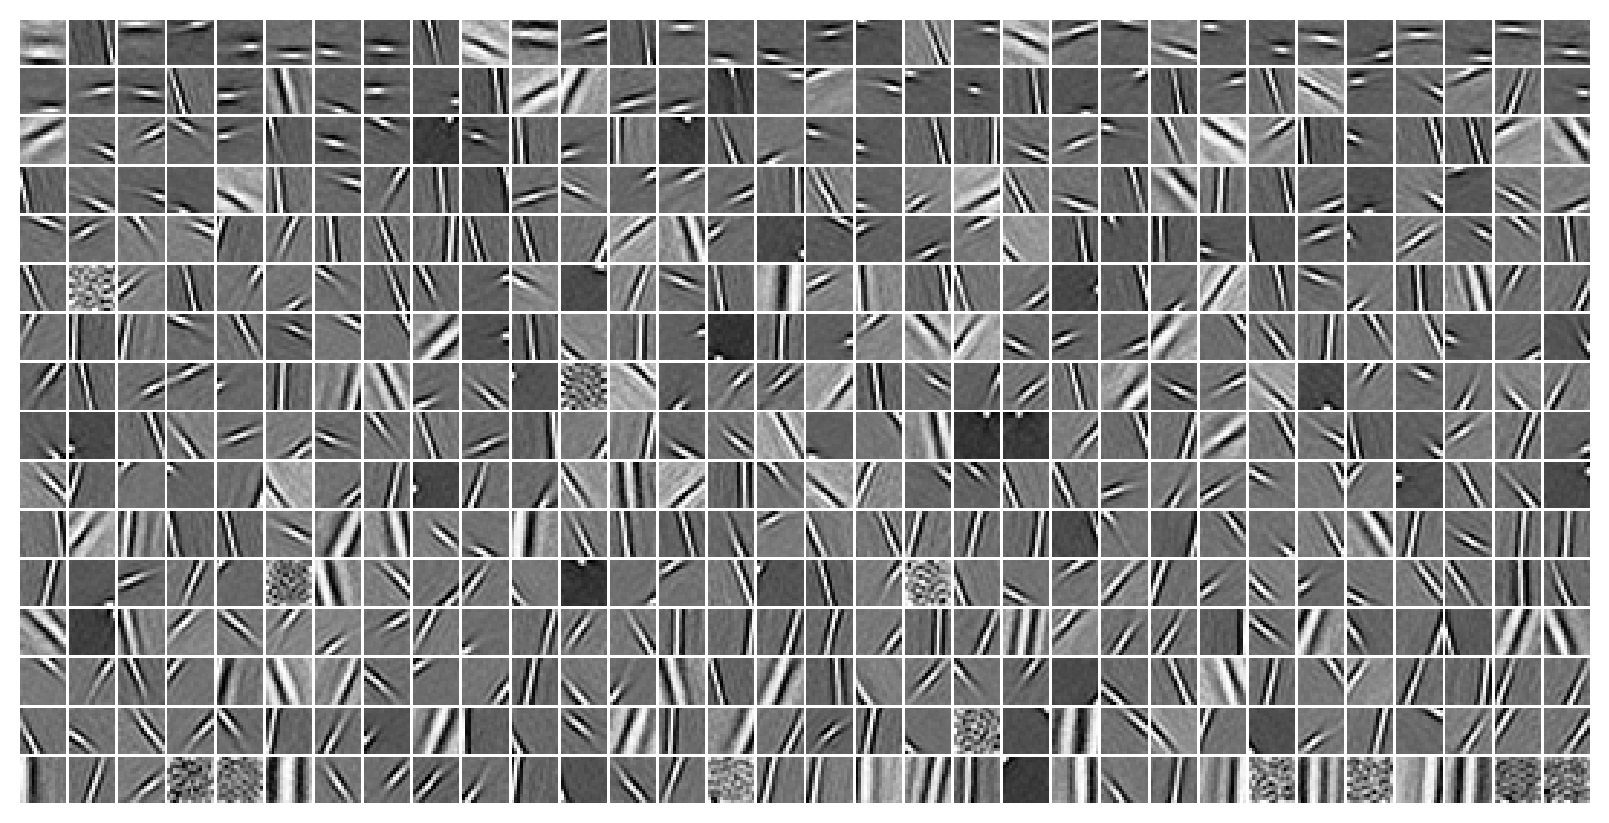

In [10]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

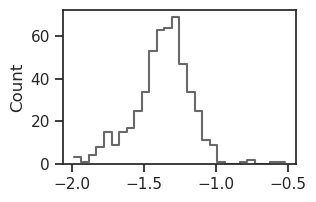

In [11]:
histplot(u0, color='dimgrey');

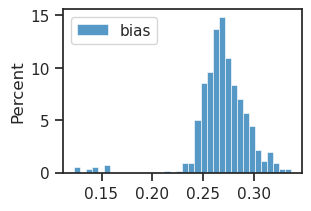

In [12]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

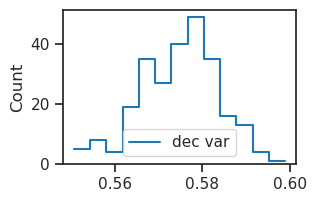

In [13]:
log_scale = tonp(tr.model.layer.log_sigma_dec.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

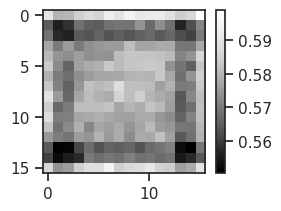

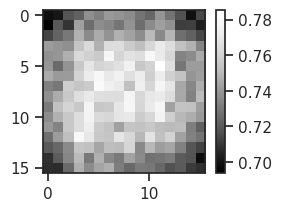

In [14]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [00:40<00:00, 20.20s/it]


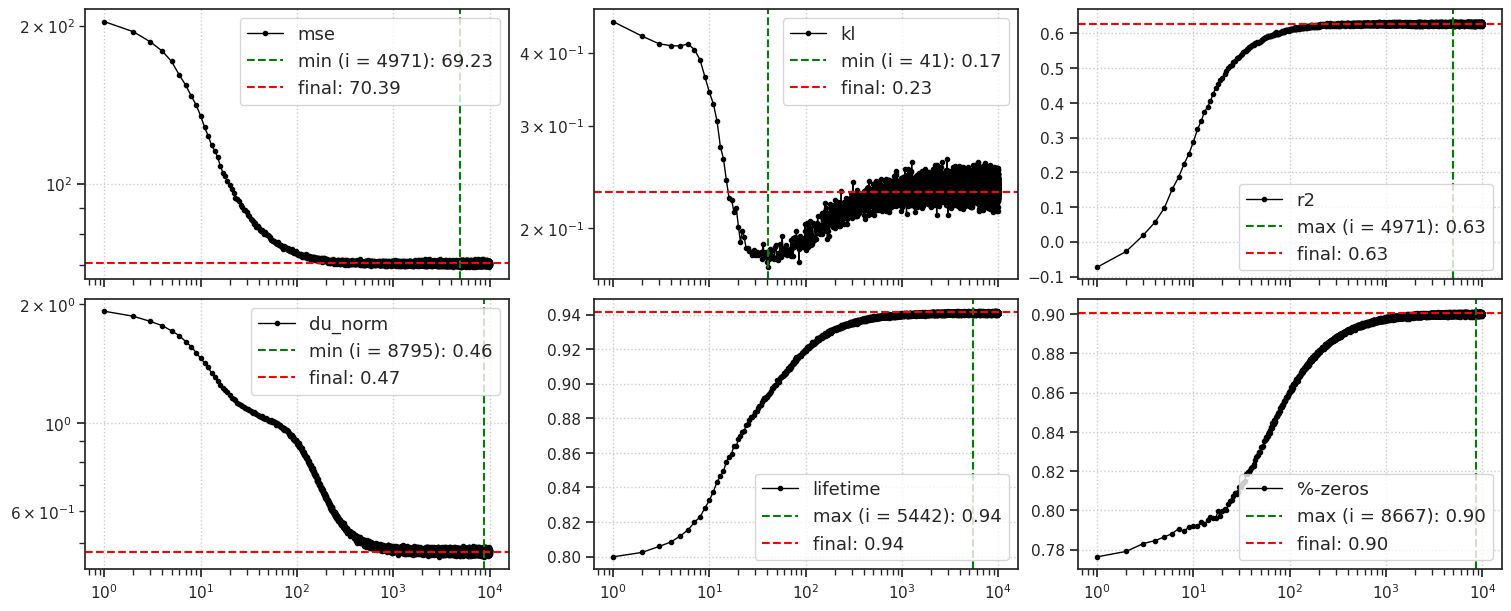

CPU times: user 49.4 s, sys: 1.89 s, total: 51.3 s
Wall time: 51.3 s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.82s/it]


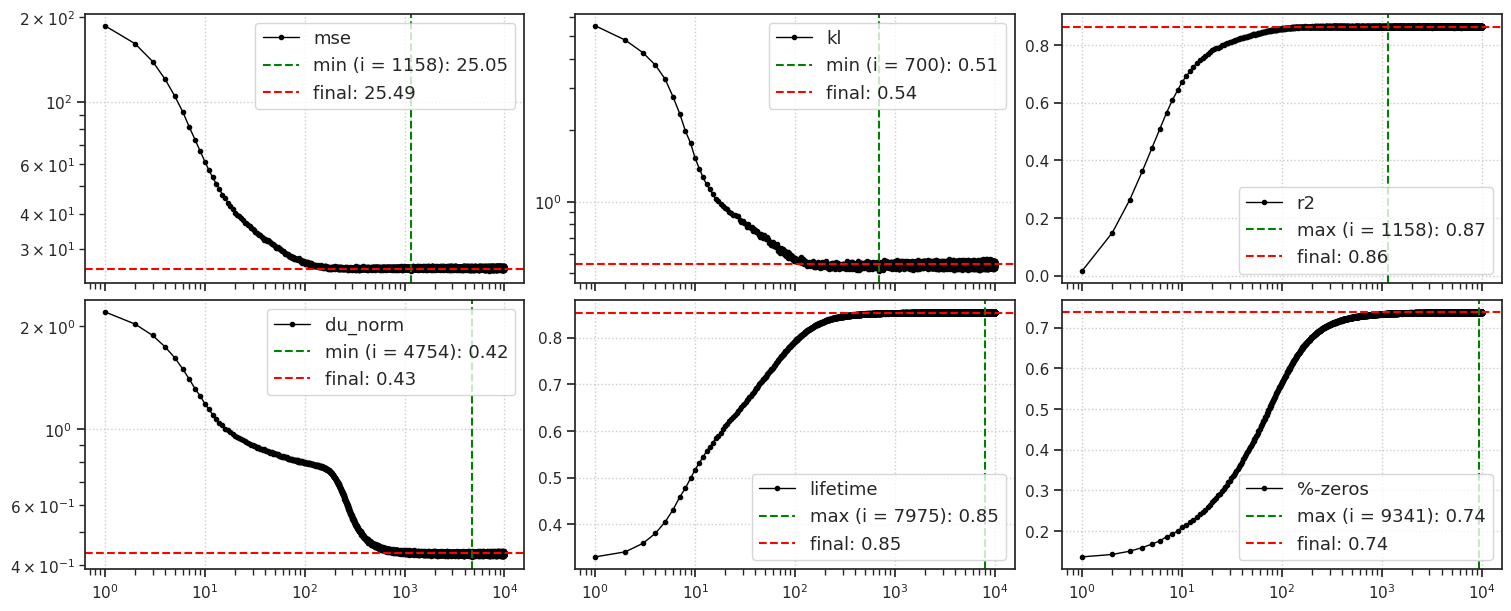

CPU times: user 50 s, sys: 2.79 s, total: 52.8 s
Wall time: 52.8 s


In [15]:
### Was: beta = 20.0

## output

In [16]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

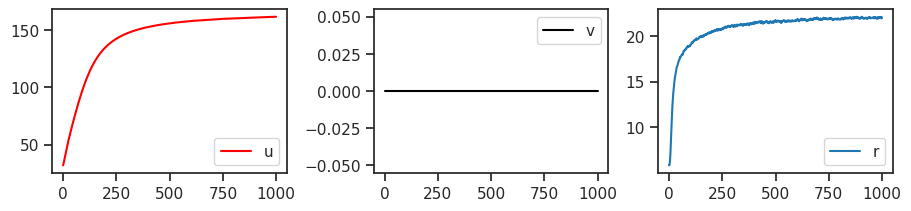

In [17]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

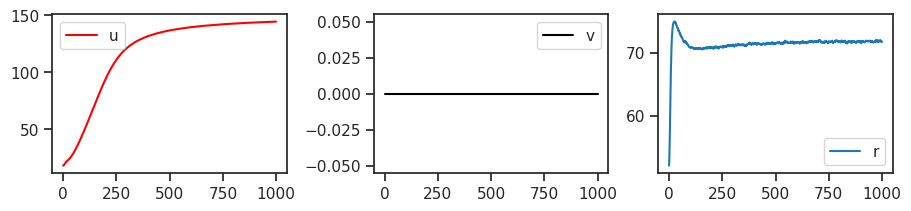

In [17]:
### Was: beta = 20.0

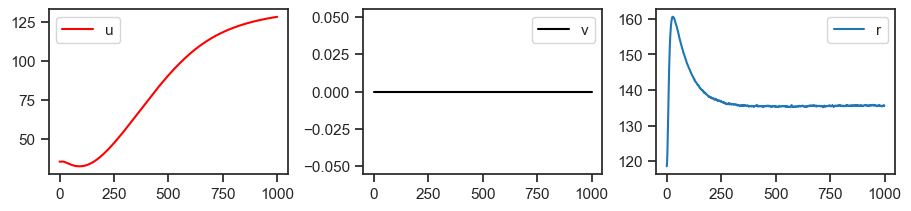

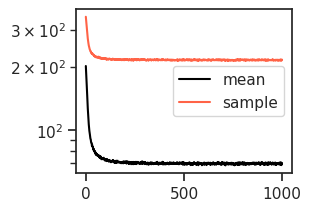

(tensor([69.0580, 68.3143, 69.9348, 69.4614, 69.6201], device='cuda:0'),
 tensor([215.5465, 214.1692, 214.9534, 216.3819, 216.3996], device='cuda:0'))

In [18]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

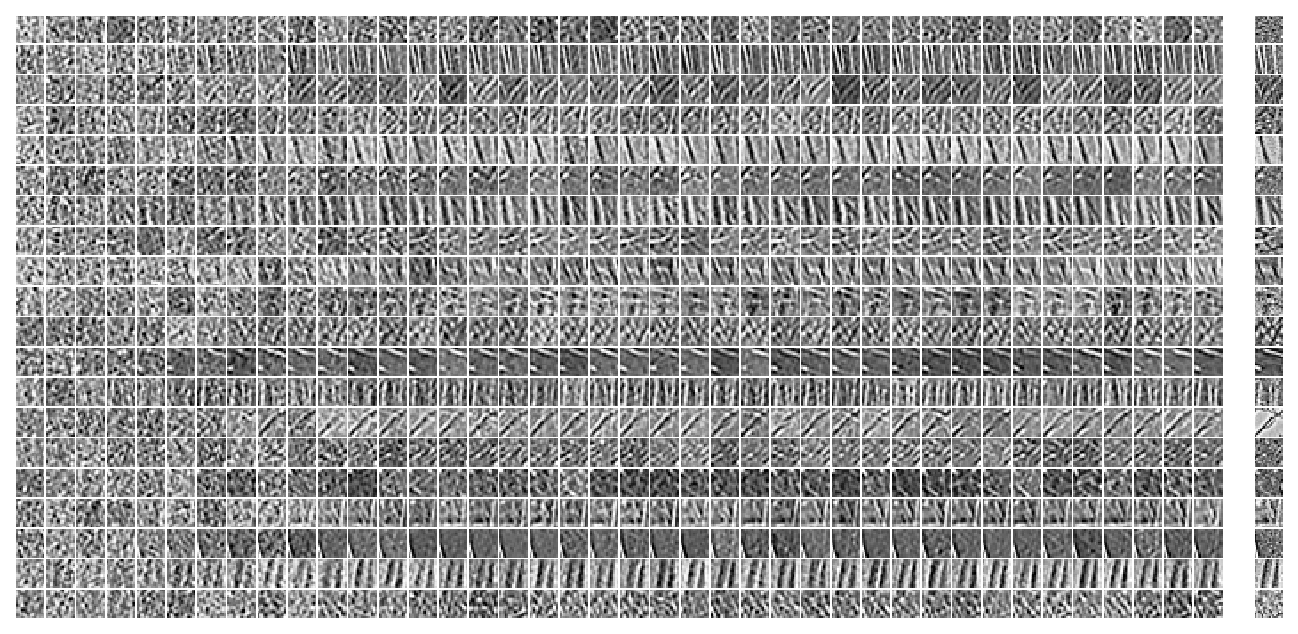

In [19]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

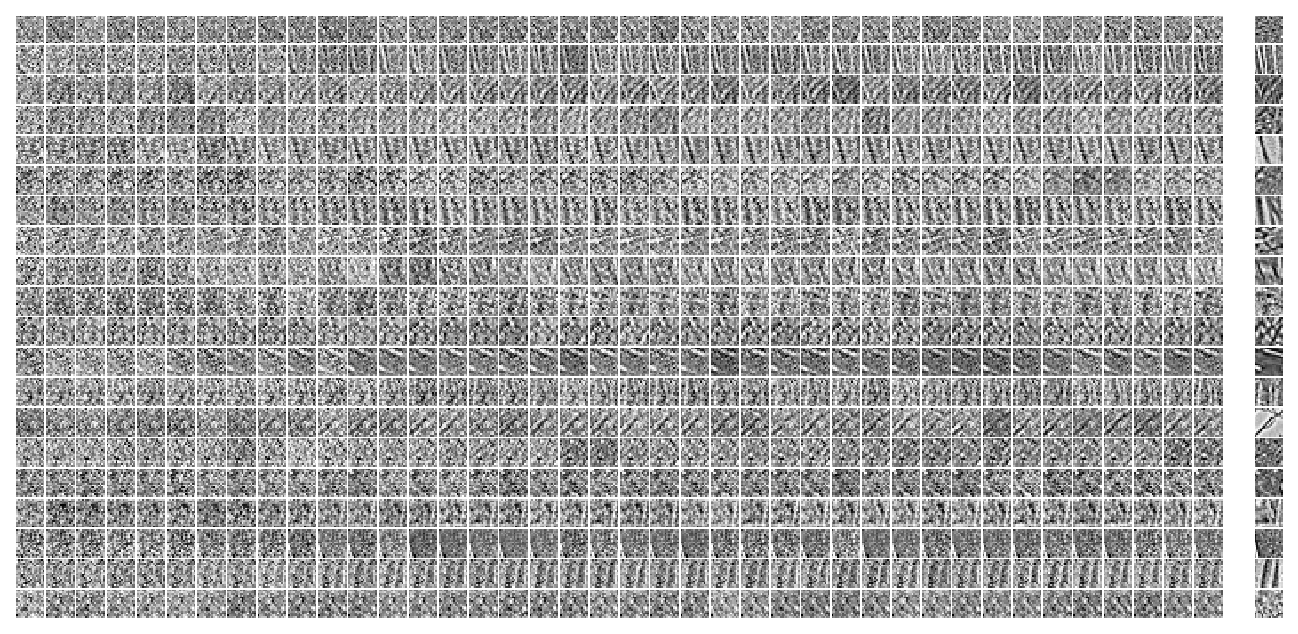

In [20]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)